# 01 · The Question and the Reflex

> Are these two groups actually different?

It is the most common statistical question in the job. Did the new feature change engagement?
Do the two cohorts differ in revenue? Is treatment better than control? And there is a reflex
answer, taught in every introductory course and available in one line in every library: the
t-test.

This notebook does two things, in this order, and the order matters:

1. **It shows the t-test working.** On clean, normal, equal-variance data it is the right tool,
   and the rest of this project has no credibility if it starts by strawmanning it.
2. **It sets up the scoring rubric** that every later notebook uses — the two ways any test can
   fail, and the simulation method that measures both against a *known* truth.

Nothing is judged here. We are agreeing on how to judge.

In [1]:
# Make the project importable whether this notebook is run from notebooks/ or the repo root.
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

In [2]:
import numpy as np

from src.config import get_settings, save_results
from src.evaluation import derive_seed, name_key
from src.evaluation.calibration import pvalue_calibration
from src.evaluation.comparison import run_arena
from src.simulation.scenarios import make_scenario
from src.tests.student import student_test
from src.tests.welch import welch_test
from src.visualisation import (
    plot_false_positive_rates,
    plot_power,
    plot_pvalue_calibration,
    plot_samples,
    save_figure,
)

settings = get_settings()
alpha = settings.alpha
n_reps = settings.reps.n_reps
figures: dict[str, str] = {}

print(f"profile={settings.profile}  alpha={alpha}  replications per cell={n_reps:,}")
print(f"master seed={settings.seed}")

profile=full  alpha=0.05  replications per cell=10,000
master seed=20250905


## The reflex, on data that deserves it

Two groups of 50, both drawn from a normal distribution with equal variances. Group b really is
shifted by 0.8 standard deviations. This is the t-test's home ground: everything it assumes is
true.

In [3]:
home_ground = make_scenario(
    "normal_equal_var", "normal", n_a=50, n_b=50, effect_d=0.8, settings=settings
)
a, b = home_ground.draw(np.random.default_rng(settings.notebooks.demo_seed))

student = student_test(a, b)
welch = welch_test(a, b)

print(f"true difference in means: {home_ground.true_mean_difference:.2f}")
print(f"observed difference:      {student.effect:.3f}")
print()
print(f"Student t = {student.statistic:6.3f}   p = {student.p_value:.5f}   reject={student.reject}")
print(f"Welch   t = {welch.statistic:6.3f}   p = {welch.p_value:.5f}   reject={welch.reject}")

true difference in means: 0.80
observed difference:      1.039

Student t =  5.934   p = 0.00000   reject=True
Welch   t =  5.934   p = 0.00000   reject=True


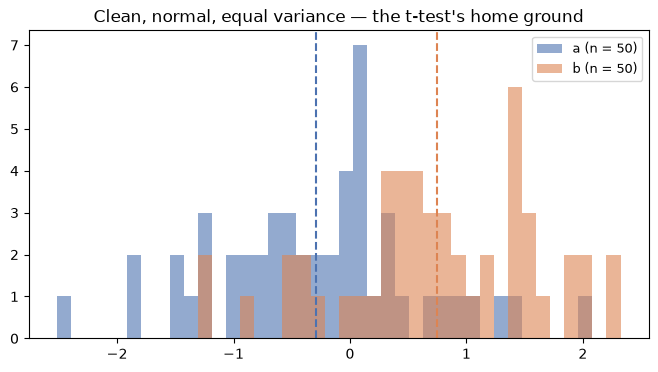

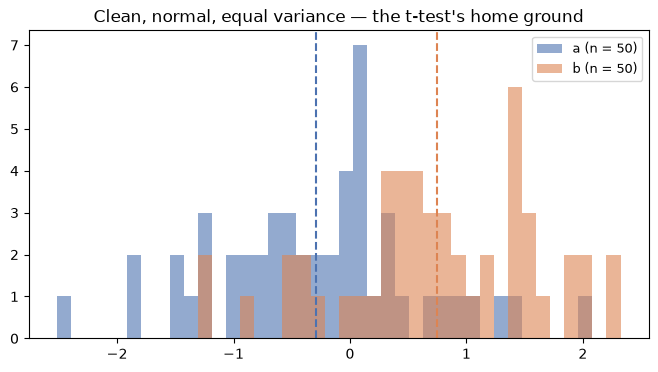

In [4]:
fig = plot_samples(a, b, title="Clean, normal, equal variance — the t-test's home ground")
figures["the_reflex"] = save_figure(fig, "01_the_reflex")
fig

The test found the effect, and the two t-tests agree to three decimal places. So far the
reflex is doing its job.

But a single run tells us nothing about whether the *procedure* is trustworthy. The p-value
above is one draw from a distribution. To judge a test we have to run it thousands of times
against a truth we control.

## The scoring rubric: two ways to fail

Any test can fail in exactly two directions.

| | The truth | What failure looks like | What we measure |
|---|---|---|---|
| **False positive** (Type I) | the groups are *identical* | the test says "significant" | rejection rate under the null — should equal α |
| **Miss** (Type II) | the groups genuinely *differ* | the test says "not significant" | 1 − power |

A false positive is a discovery that is not there. A miss is a real effect you walked past. The
first is the more expensive one, because it gets published, shipped and believed.

The measurement method is the same for both: simulate from a population whose truth we know,
run the test thousands of times, and count. That is the only way to grade a test — you cannot
tell from a single p-value whether the procedure that produced it is honest.

**Always read a simulated rate next to its Monte Carlo error.** At 10,000 replications the
standard error of a rate near 0.05 is about 0.0022, so "0.054 versus 0.050" is noise and
"0.375 versus 0.050" is not.

In [5]:
null_and_effect = [home_ground.with_effect(0.0), home_ground.with_effect(0.8)]
tests = {"student": student_test, "welch": welch_test}

clean = run_arena(null_and_effect, tests=tests, settings=settings, cache=False)
clean[["scenario", "test", "metric", "reject_rate", "mc_se", "target"]]

,scenario,test,metric,reject_rate,mc_se,target
0,normal_equal_var::null,student,fpr,0.0496,0.002171,0.05
1,normal_equal_var::null,welch,fpr,0.0495,0.002169,0.05
2,normal_equal_var::effect,student,power,0.9775,0.001483,NaN
3,normal_equal_var::effect,welch,power,0.9775,0.001483,NaN


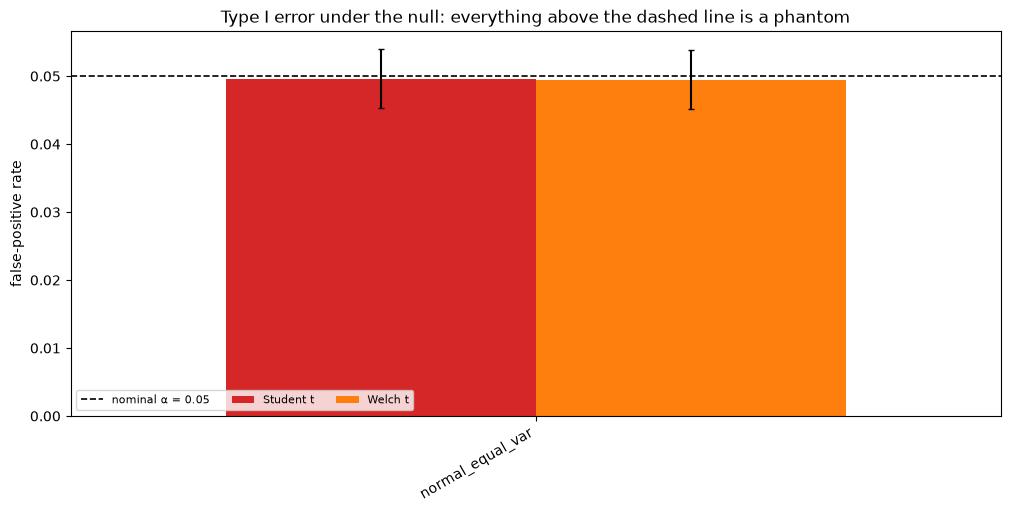

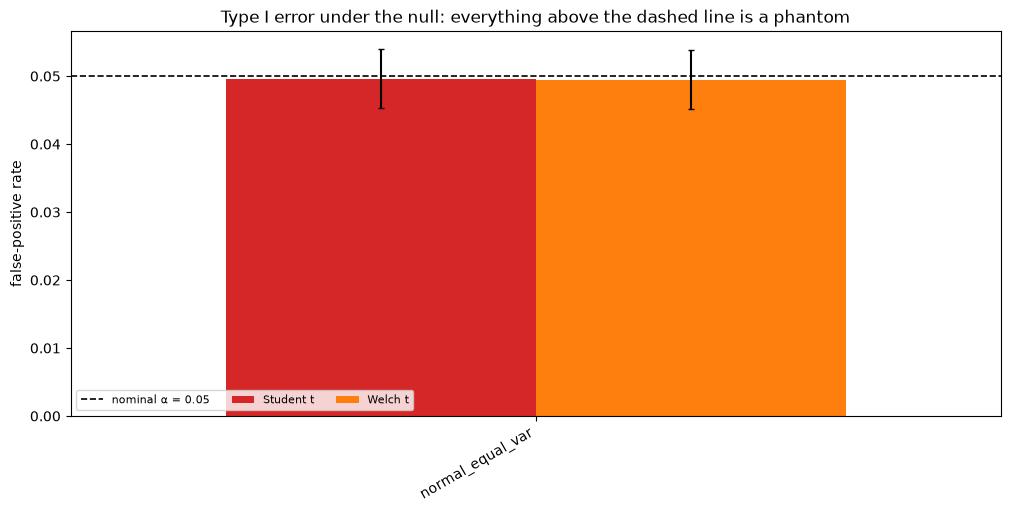

In [6]:
fig = plot_false_positive_rates(clean, alpha=alpha)
figures["type_one_error_clean"] = save_figure(fig, "01_type_one_error_clean")
fig

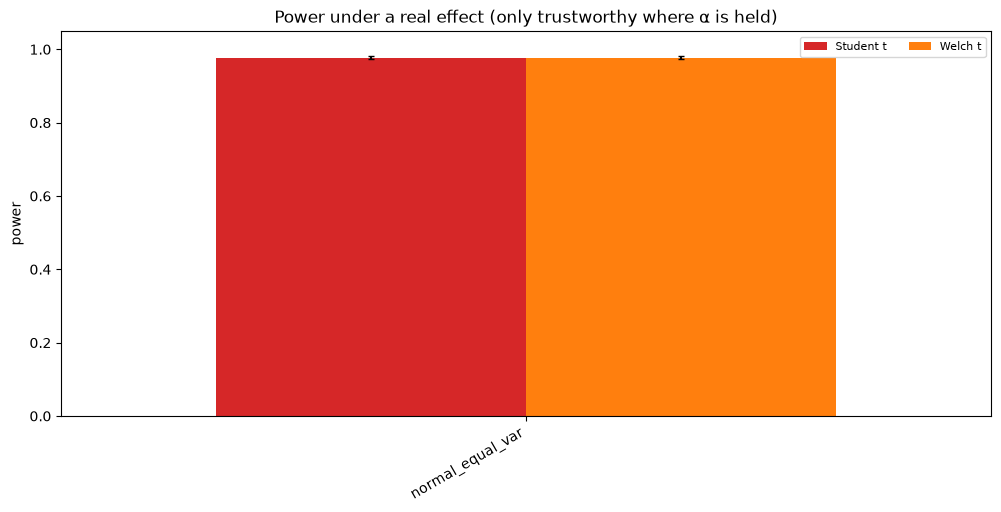

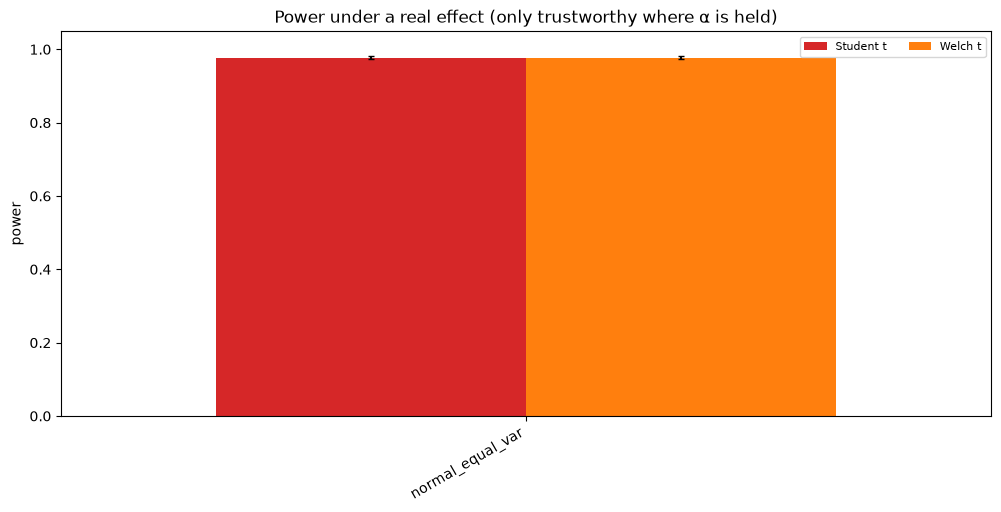

In [7]:
fig = plot_power(clean)
figures["power_clean"] = save_figure(fig, "01_power_clean")
fig

Both t-tests land on α when nothing is going on, and both catch the real effect about 98% of
the time. **On this data the t-test is not broken and is not going to be criticised.** Hold on
to that: it is the control condition for everything that follows.

## The sharper version of the same check

"Rejects 5% of the time at α = 0.05" is weaker than it sounds. A valid test rejects at exactly α
*for every* α at once — which is the same statement as: **under the null, its p-values are
uniformly distributed on (0, 1)**.

That is the check that will do the real work in notebook 02, so here is what passing it looks
like.

In [8]:
# The same seed derivation run_arena uses, so these numbers are the *same* measurement as
# the table above rather than an independent one that happens to be close.
null_scenario = home_ground.with_effect(0.0)
calibration = [
    pvalue_calibration(
        test_fn,
        null_scenario,
        n_reps=n_reps,
        alpha=alpha,
        data_seed=derive_seed(settings.seed, name_key(null_scenario.name)),
        test_seed=derive_seed(settings.seed, name_key(null_scenario.name), name_key(name)),
        test_name=name,
    )
    for name, test_fn in tests.items()
]
for result in calibration:
    print(
        f"{result.test:<8} rejection rate at α={alpha}: {result.rejection_rate:.4f}   "
        f"KS distance from uniform: {result.ks_statistic:.4f}   uniform? {result.is_uniform()}"
    )

student  rejection rate at α=0.05: 0.0496   KS distance from uniform: 0.0147   uniform? True
welch    rejection rate at α=0.05: 0.0495   KS distance from uniform: 0.0148   uniform? True


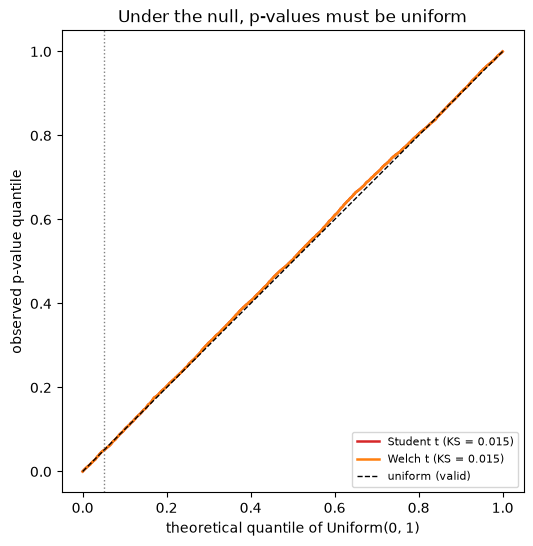

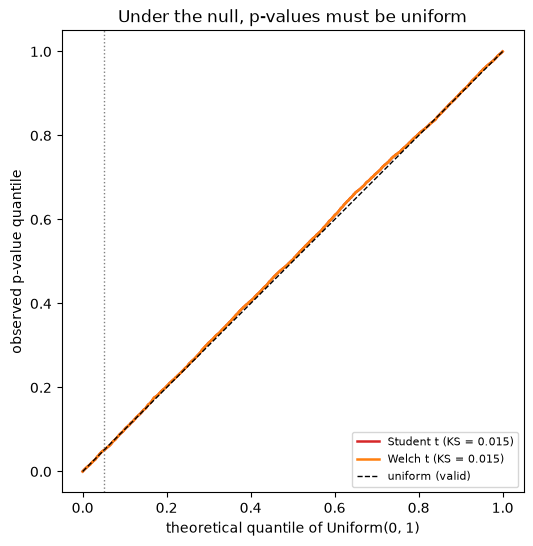

In [9]:
fig = plot_pvalue_calibration(calibration, alpha=alpha)
figures["calibration_clean"] = save_figure(fig, "01_calibration_clean")
fig

On the diagonal. That is what a valid test looks like, and it is the picture to keep in mind
when notebook 02 shows the same plot bending away from it.

## What we have established

- The t-test works, and works well, when its assumptions hold.
- A test is judged by two rates measured against a known truth: false positives under the null,
  power under a real effect.
- Every rate carries Monte Carlo error, and a gap smaller than a few standard errors is not a
  finding.
- The strictest version of "valid" is that null p-values are uniform.

Next: the same rubric, applied to data that breaks the assumptions.

In [10]:
summary = {
    "notebook": "01_the_question_and_the_reflex",
    "settings": {
        "profile": settings.profile,
        "alpha": alpha,
        "n_reps": n_reps,
        "seed": settings.seed,
        "demo_seed": settings.notebooks.demo_seed,
    },
    "single_comparison": {
        "scenario": home_ground.name,
        "n_a": home_ground.n_a,
        "n_b": home_ground.n_b,
        "true_mean_difference": home_ground.true_mean_difference,
        "observed_difference": student.effect,
        "student": {"t": student.statistic, "p_value": student.p_value, "reject": student.reject},
        "welch": {"t": welch.statistic, "p_value": welch.p_value, "reject": welch.reject},
    },
    "clean_data_rates": clean,
    "calibration": [
        {
            "test": r.test,
            "scenario": r.scenario,
            "rejection_rate": r.rejection_rate,
            "ks_statistic": r.ks_statistic,
            "ks_p_value": r.ks_p_value,
            "is_uniform": r.is_uniform(),
            "n_reps": r.n_reps,
        }
        for r in calibration
    ],
    "figures": figures,
    "claims": [
        "On clean normal equal-variance data the Student and Welch t-tests both hold their "
        f"false-positive rate at the nominal {alpha} and both detect a 0.8 sd effect at n=50 "
        "per group.",
        "A test is graded by two rates against a known truth: false positives under the null "
        "and power under a real effect; neither is readable without its Monte Carlo error.",
        "The strict form of validity is that null p-values are Uniform(0, 1); on clean data "
        "both t-tests trace the diagonal.",
    ],
}
print(save_results("01_the_question_and_the_reflex", summary))

/workspaces/hypothesis_testing_arena/outputs/results/01_the_question_and_the_reflex.json
